# FReT on Dynamical Systems

This notebook demonstrates the FReT algorithm on real dynamical systems — the Rössler attractor, the Lorenz attractor, and the Mackey-Glass time series. For the Rössler and Lorenz systems, the data consists of three signals (X, Y, Z), and FReT forecasts each one separately. Mackey-Glass is a univariate time series, tested with multiple forecast horizons.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from fret import FReT_forecast, mae

# Rossler

## Data

In [2]:
rossler = np.genfromtxt("../data/Rossler.csv", delimiter=",")

In [3]:
X = rossler[:, 0]
Y = rossler[:, 1]
Z = rossler[:, 2]

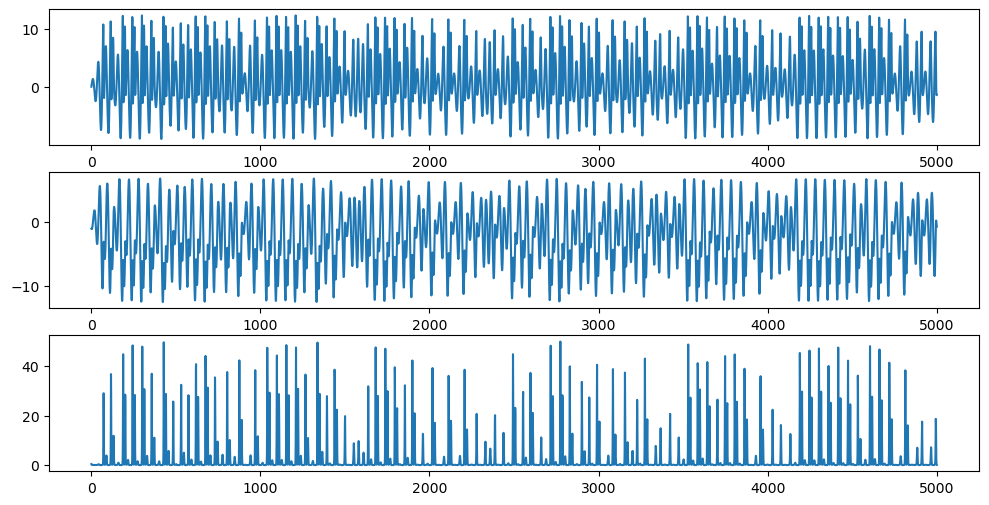

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(X)

plt.subplot(3, 1, 2)
plt.plot(Y)

plt.subplot(3, 1, 3)
plt.plot(Z)

## Forecast and Plot

In [5]:
def plot_forecast(x_test, forecast, label, save=False, fname=""):
    plt.figure(figsize=(12, 6))
    plt.plot(x_test, linewidth=4, color="black", label=label)
    plt.plot(forecast, "--", linewidth=4, color="red", label="FReT")
    plt.text(
        0.01,
        0.99,
        f"MAE = {np.round(mae(x_test, forecast), 2)}",
        fontsize=14,
        ha="left",
        va="top",
        transform=plt.gca().transAxes,
    )
    plt.legend(loc="upper right")
    if save:
        plt.savefig(fname)

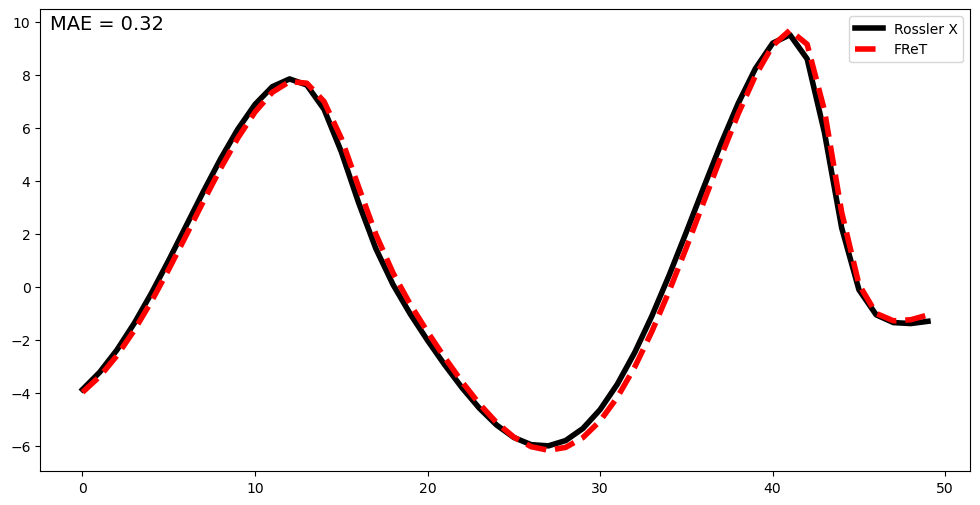

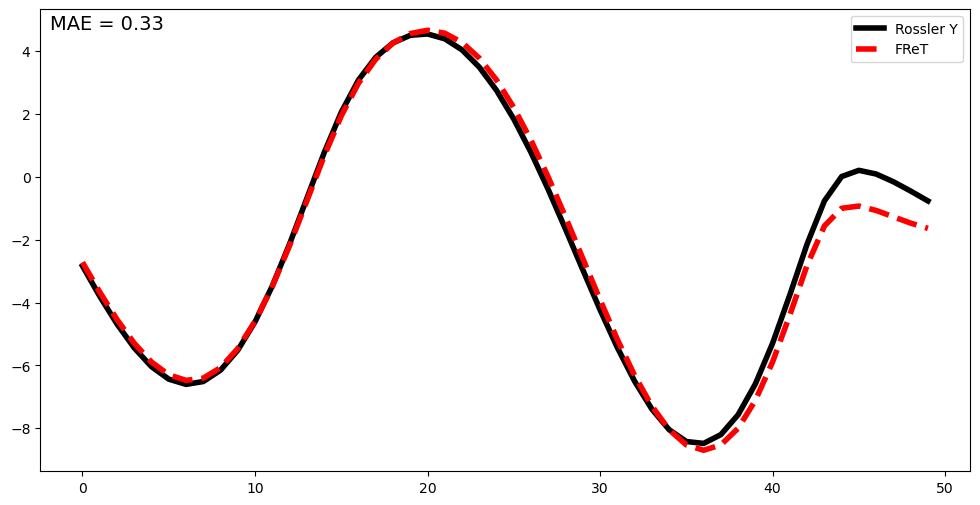

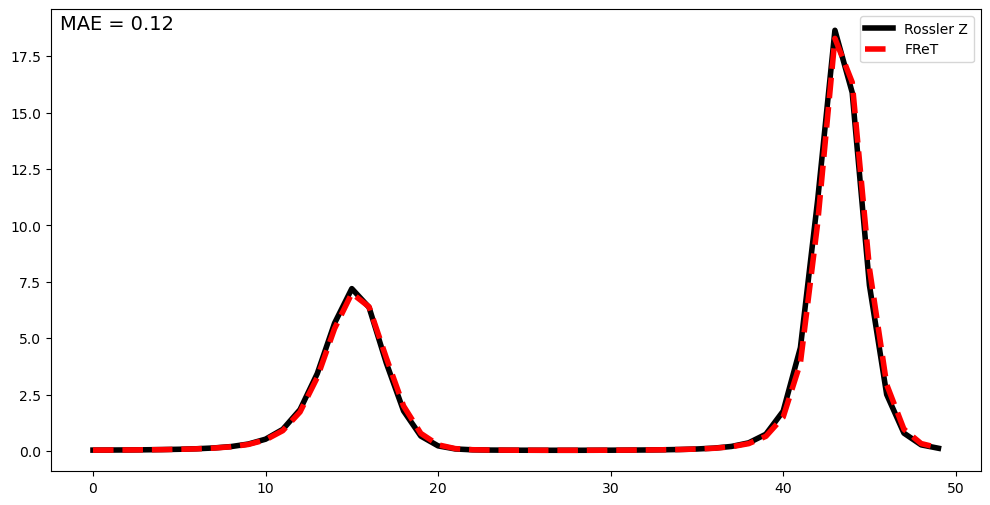

In [6]:
for signal, name in zip([X, Y, Z], ["X", "Y", "Z"]):
    horizon = 50
    x_train = signal[:-horizon].reshape(-1, 1)
    x_test = signal[-horizon:].reshape(-1, 1)

    forecast = FReT_forecast(x_train, forecast_horizon=horizon)

    plot_forecast(x_test, forecast, label=f"Rossler {name}", save=False)

# Lorenz

Now we apply the same approach to the Lorenz attractor. The Lorenz system has three variables (X, Y, Z), and we forecast each one separately using FReT.

In [7]:
lorenz = np.genfromtxt("../data/Lorenz.csv", delimiter=",")

In [8]:
X_lorenz = lorenz[:, 0]
Y_lorenz = lorenz[:, 1]
Z_lorenz = lorenz[:, 2]

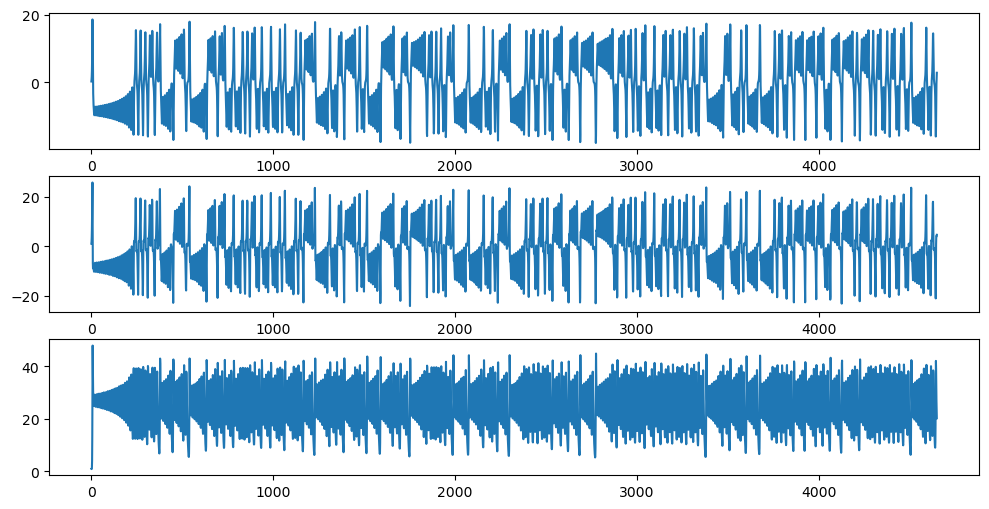

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(X_lorenz)

plt.subplot(3, 1, 2)
plt.plot(Y_lorenz)

plt.subplot(3, 1, 3)
plt.plot(Z_lorenz)

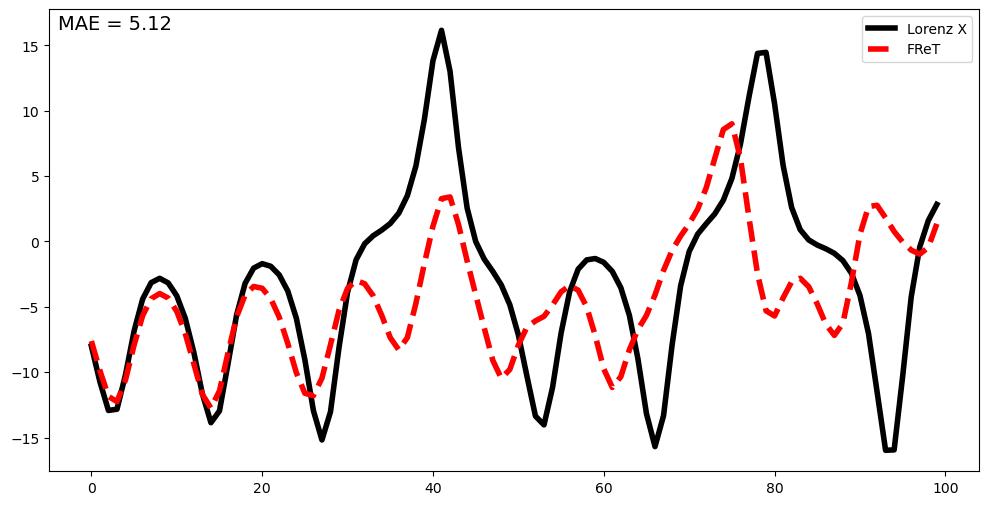

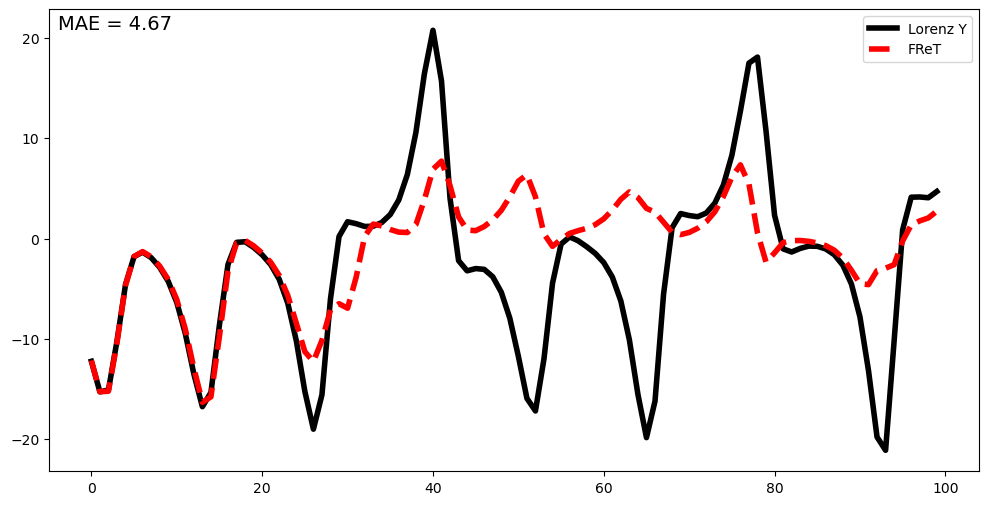

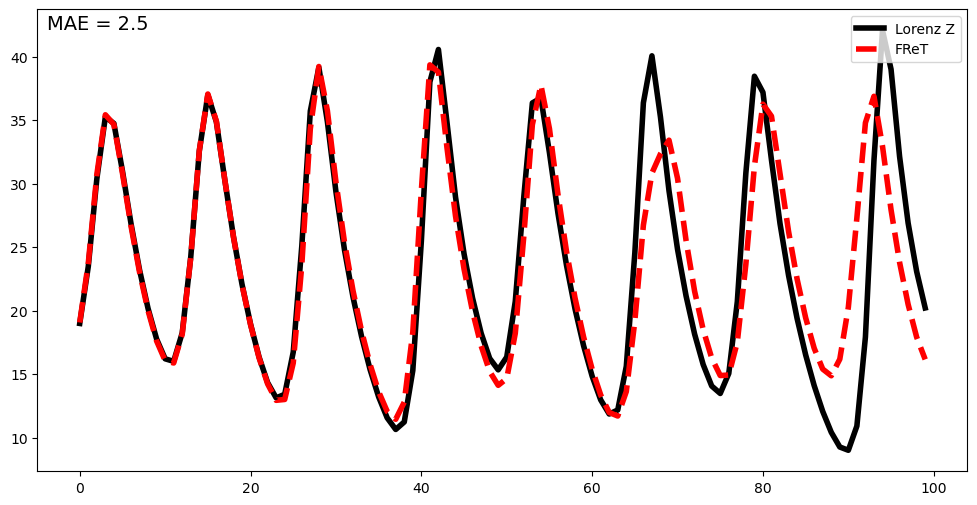

In [10]:
for signal, name in zip([X_lorenz, Y_lorenz, Z_lorenz], ["X", "Y", "Z"]):
    horizon = 100
    x_train = signal[:-horizon].reshape(-1, 1)
    x_test = signal[-horizon:].reshape(-1, 1)

    forecast = FReT_forecast(x_train, forecast_horizon=horizon)

    plot_forecast(x_test, forecast, label=f"Lorenz {name}", save=False)

## Mackey-Glass

The Mackey-Glass system is a delay differential equation that exhibits chaotic behavior. Unlike the Rössler and Lorenz attractors which have multiple variables, Mackey-Glass is a univariate time series (single X component). Below we test multiple forecast horizons (50, 100, 150 steps).

In [11]:
mackeyglass = np.genfromtxt("../data/MackeyGlass.csv", delimiter=",")
mackeyglass = mackeyglass[1:, 0]  # Skip NaN row, use first column

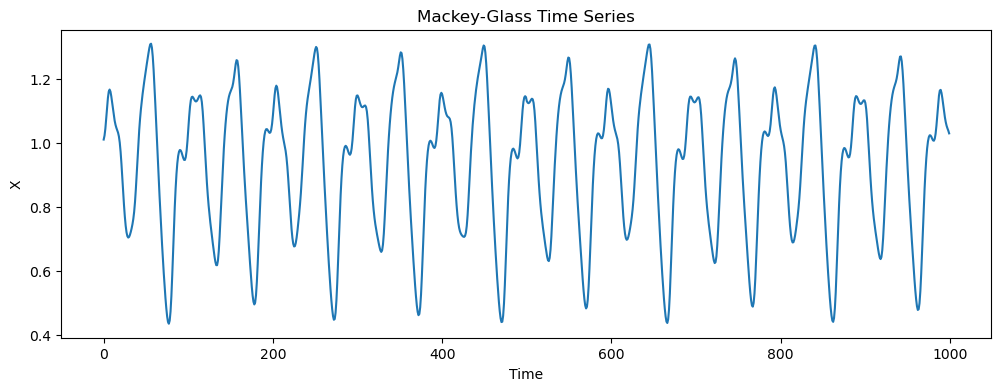

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(mackeyglass)
plt.title("Mackey-Glass Time Series")
plt.xlabel("Time")
plt.ylabel("X")
plt.show()

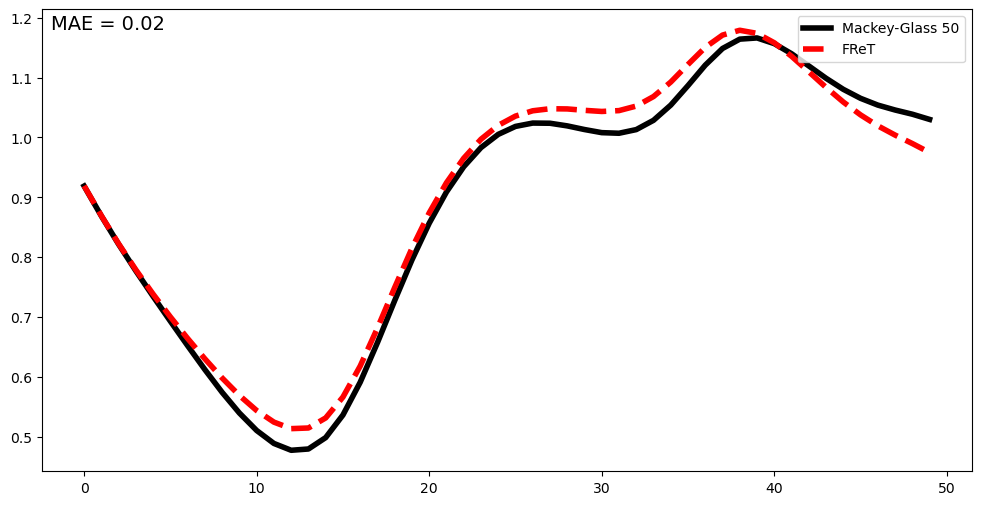

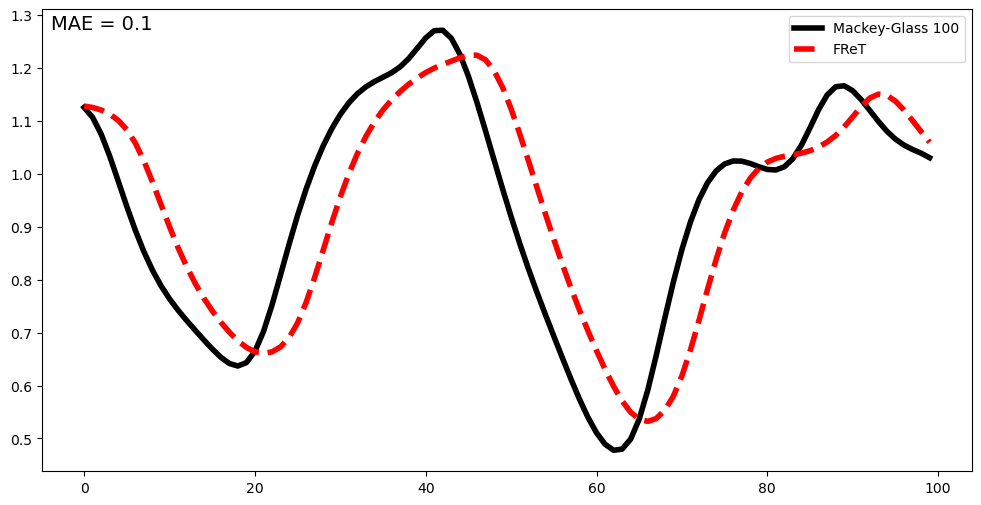

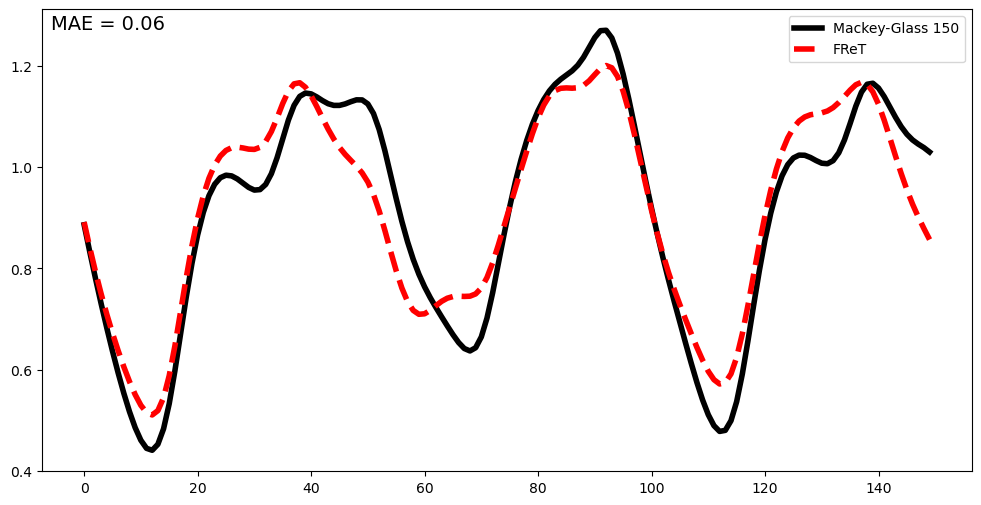

In [13]:
signal = mackeyglass
for horizon in [50, 100, 150]:
    x_train = signal[:-horizon].reshape(-1, 1)
    x_test = signal[-horizon:].reshape(-1, 1)

    forecast = FReT_forecast(x_train, forecast_horizon=horizon)

    plot_forecast(x_test, forecast, label=f"Mackey-Glass {horizon}", save=False)